In [1]:
import tensorflow as tf
import os
import cv2
import numpy as np

IMG_ROW_SIZE = 384
IMG_COL_SIZE = 512
BATCH = 8

In [2]:


img_dir  = "images"
mask_dir = "labels"

images = sorted(os.listdir(img_dir))
labels = sorted(os.listdir(mask_dir))


X = []
Y = []

for img_name in images:
    
    img = cv2.imread(os.path.join(img_dir, img_name))
    img = img / 255.0
    X.append(img)

for label_name in labels:
    
    mask = cv2.imread(os.path.join(mask_dir, label_name),0)
    mask = np.expand_dims(mask,-1)
    Y.append(mask)

X = np.array(X)
Y = np.array(Y)

print(X[0])


[[[0.12941176 0.18431373 0.17647059]
  [0.05490196 0.10980392 0.10196078]
  [0.07843137 0.13333333 0.1254902 ]
  ...
  [0.05098039 0.07843137 0.06666667]
  [0.04313725 0.07058824 0.05882353]
  [0.07843137 0.10588235 0.09411765]]

 [[0.10980392 0.16470588 0.15686275]
  [0.05098039 0.10588235 0.09803922]
  [0.06666667 0.12156863 0.11372549]
  ...
  [0.0627451  0.09019608 0.07843137]
  [0.05098039 0.07843137 0.06666667]
  [0.07843137 0.10588235 0.09411765]]

 [[0.07058824 0.1372549  0.1254902 ]
  [0.04705882 0.11372549 0.10196078]
  [0.07843137 0.14509804 0.13333333]
  ...
  [0.07058824 0.09803922 0.08627451]
  [0.0627451  0.09019608 0.07843137]
  [0.0745098  0.10196078 0.09019608]]

 ...

 [[0.09803922 0.20392157 0.19215686]
  [0.09803922 0.20392157 0.19215686]
  [0.11372549 0.2        0.19215686]
  ...
  [0.12156863 0.15294118 0.14901961]
  [0.14509804 0.17647059 0.17254902]
  [0.12941176 0.16078431 0.15686275]]

 [[0.09411765 0.19607843 0.19607843]
  [0.09019608 0.19215686 0.19215686]


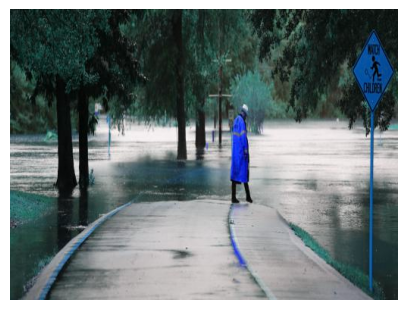

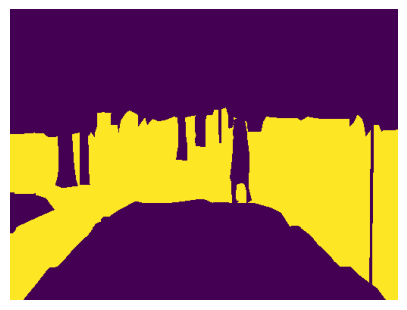

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize = (5,6))
plt.imshow(X[0])
plt.axis("off")
plt.show()

plt.figure(figsize = (5,6))
plt.imshow(Y[0])
plt.axis("off")
plt.show()


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [5]:
X_train[0].shape

(384, 512, 3)

In [ ]:
import tensorflow as tf

# =====================================================
# Local Attention Layer
# =====================================================

class LocalAttention(tf.keras.layers.Layer):
    def __init__(self, filters):
        super(LocalAttention, self).__init__()

        self.local_context = tf.keras.layers.DepthwiseConv2D(
            kernel_size=5,
            padding='same',
            activation='relu'
        )

        self.attn = tf.keras.layers.Conv2D(
            filters,
            1,
            activation='sigmoid'
        )

    def call(self, x):
        local_feat = self.local_context(x)
        weights = self.attn(local_feat)

        return x * weights + x


# =====================================================
# Model
# =====================================================

inputs = tf.keras.Input(shape=(IMG_ROW_SIZE, IMG_COL_SIZE, 3))

# Encoder
x1 = tf.keras.layers.Conv2D(
    32, 3, activation='relu', padding='same'
)(inputs)

x1 = LocalAttention(32)(x1)

p1 = tf.keras.layers.MaxPool2D()(x1)


x2 = tf.keras.layers.Conv2D(
    64, 3, activation='relu', padding='same'
)(p1)

x2 = LocalAttention(64)(x2)

p2 = tf.keras.layers.MaxPool2D()(x2)


# Bottleneck
x3 = tf.keras.layers.Conv2D(
    128, 3, activation='relu', padding='same'
)(p2)

x3 = LocalAttention(128)(x3)


# Decoder
u1 = tf.keras.layers.UpSampling2D()(x3)

u1 = tf.keras.layers.Conv2D(
    64, 3, activation='relu', padding='same'
)(u1)

u1 = LocalAttention(64)(u1)


u2 = tf.keras.layers.UpSampling2D()(u1)

u2 = tf.keras.layers.Conv2D(
    32, 3, activation='relu', padding='same'
)(u2)

u2 = LocalAttention(32)(u2)


outputs = tf.keras.layers.Conv2D(
    1, 1, activation='sigmoid'
)(u2)


model = tf.keras.Model(inputs, outputs)

# =====================================================
# Compile
# =====================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =====================================================
# Train
# =====================================================

model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=BATCH,
    validation_data=(X_test, Y_test)
)

model.evaluate(X_test, Y_test)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 460s 10s/step - accuracy: 0.6323 - loss: 0.6196 - val_accuracy: 0.6949 - val_loss: 0.5937
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 400s 9s/step - accuracy: 0.6902 - loss: 0.5750 - val_accuracy: 0.6666 - val_loss: 0.5868
Epoch 3/10
33/44 ━━━━━━━━━━━━━━━━━━━━ 12:48 70s/step - accuracy: 0.6842 - loss: 0.5814

KeyboardInterrupt: 

In [7]:
pred = model.predict(X_test)
pred_mask = (pred > 0.5).astype(np.uint8)


3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step


In [ ]:
model.save("local_attention.keras")


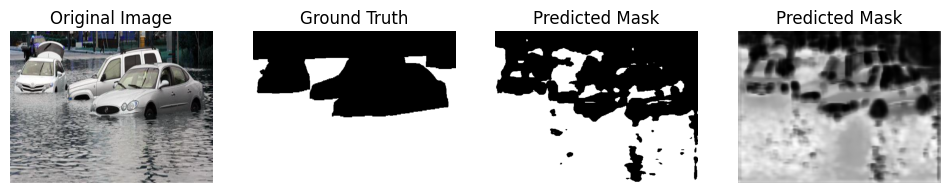

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(X_test[0])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(Y_test[0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask[0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(pred[0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [ ]:
print(X_train[0].shape)

(384, 512, 3)


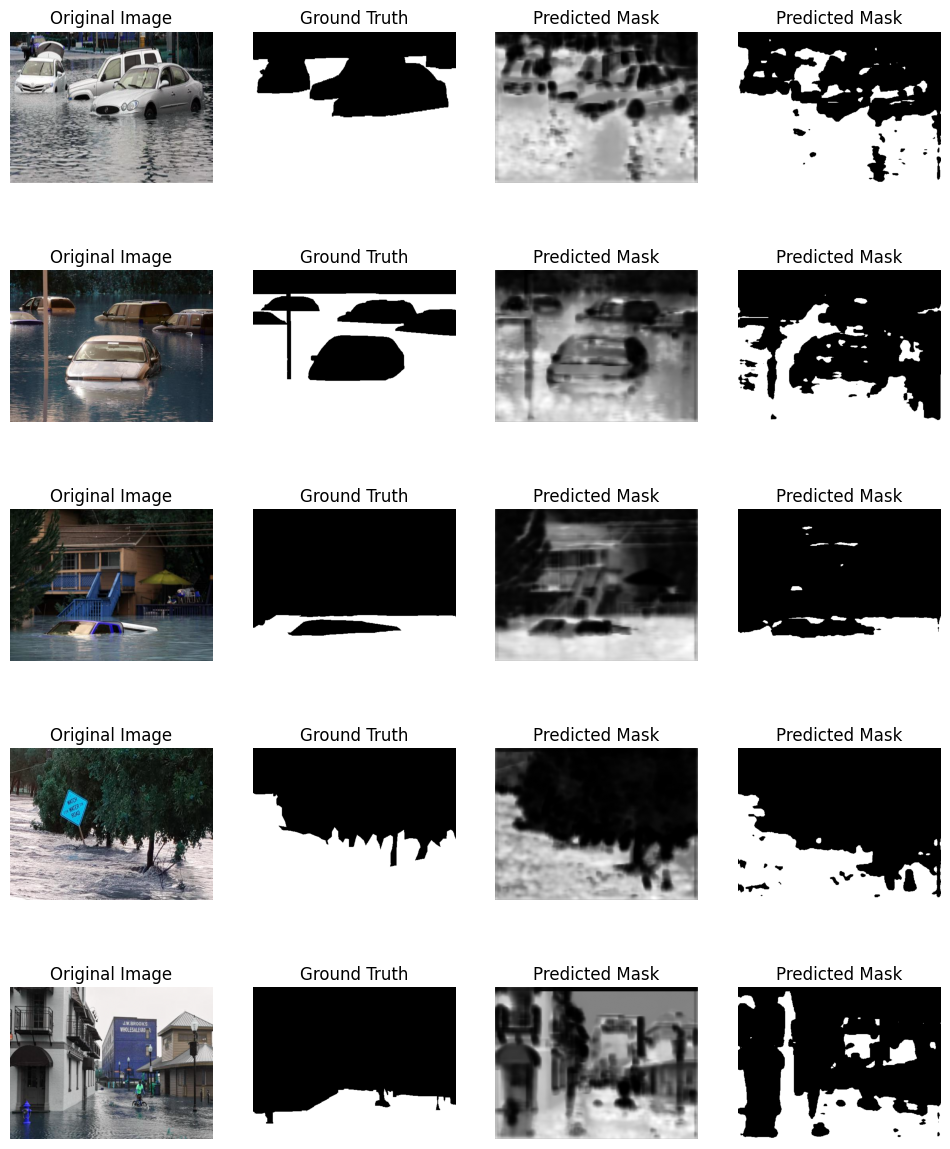

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,15))

for i in range(5):
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(X_test[i])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(5, 4, i*4 + 2)
    plt.imshow(Y_test[i], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5, 4, i*4 + 3)
    plt.imshow(pred[i], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(5, 4, i*4 + 4)
    plt.imshow(pred_mask[i], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")



plt.show()

In [ ]:
X_train[0].shape

(384, 512, 3)

In [ ]:
# UNET architecture with dice loss...more advanced..

import tensorflow as tf


def dice_loss(y_true, y_pred):

    smooth = 1e-6
    
    y_true = tf.cast(y_true, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    
    dice = (2 * intersection + smooth) / (union + smooth)
    
    return 1 - tf.reduce_mean(dice)

def combined_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    
    d = dice_loss(y_true, y_pred)
    
    return bce + d

inputs = tf.keras.layers.Input(shape=(384, 512, 3))
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])
x = data_augmentation(inputs)
# ----- Encoder -----

c1 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(x)
c1 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(c1)
p1 = tf.keras.layers.MaxPool2D()(c1)

c2 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(p1)
c2 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(c2)
p2 = tf.keras.layers.MaxPool2D()(c2)

c3 = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(p2)
c3 = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(c3)
p3 = tf.keras.layers.MaxPool2D()(c3)

c4 = tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(p3)
c4 = tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(c4)
p4 = tf.keras.layers.MaxPool2D()(c4)

# ----- Bottleneck -----

bn = tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(p4)
bn = tf.keras.layers.Conv2D(512,3,activation='relu',padding='same')(bn)

# ----- Decoder -----

u1 = tf.keras.layers.UpSampling2D()(bn)
u1 = tf.keras.layers.Concatenate()([u1, c4])
c5 = tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(u1)
c5 = tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(c5)

u2 = tf.keras.layers.UpSampling2D()(c5)
u2 = tf.keras.layers.Concatenate()([u2, c3])
c6 = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(u2)
c6 = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(c6)

u3 = tf.keras.layers.UpSampling2D()(c6)
u3 = tf.keras.layers.Concatenate()([u3, c2])
c7 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(u3)
c7 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(c7)

u4 = tf.keras.layers.UpSampling2D()(c7)
u4 = tf.keras.layers.Concatenate()([u4, c1])
c8 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(u4)
c8 = tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(c8)

# ----- Output -----

outputs = tf.keras.layers.Conv2D(1,1,activation='sigmoid')(c8)

model2 = tf.keras.Model(inputs, outputs)
model2.compile(
    optimizer='adam',
    loss= combined_loss,
    metrics=['accuracy']
)

history = model2.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=BATCH,
    validation_data=(X_test, Y_test)
)

model2.evaluate(X_test, Y_test)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 500s 11s/step - accuracy: 0.5140 - loss: 1.2606 - val_accuracy: 0.6033 - val_loss: 1.2013
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 499s 11s/step - accuracy: 0.5673 - loss: 1.2262 - val_accuracy: 0.7606 - val_loss: 1.0440
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 477s 11s/step - accuracy: 0.6021 - loss: 1.1999 - val_accuracy: 0.7949 - val_loss: 0.8657
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 595s 14s/step - accuracy: 0.7139 - loss: 1.0386 - val_accuracy: 0.8004 - val_loss: 0.9366
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 471s 11s/step - accuracy: 0.7187 - loss: 0.9953 - val_accuracy: 0.7794 - val_loss: 0.9234
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 493s 11s/step - accuracy: 0.7241 - loss: 1.0032 - val_accuracy: 0.8122 - val_loss: 0.8447
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 512s 12s/step - accuracy: 0.7199 - loss: 0.9849 - val_accuracy: 0.8071 - val_loss: 0.8303
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 489s 11s/step - accuracy: 0.7336 - loss: 0.9521 - val_accuracy: 0.

[0.7662946581840515, 0.8210667967796326]

In [ ]:
# history2 = model2.fit(
#     X_train,
#     Y_train,
#     epochs=8,
#     batch_size=BATCH,
#     validation_data=(X_test, Y_test)
# )

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 508s 11s/step - accuracy: 0.7313 - loss: 0.9535 - val_accuracy: 0.8154 - val_loss: 0.8458
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 499s 11s/step - accuracy: 0.7151 - loss: 0.9858 - val_accuracy: 0.8121 - val_loss: 0.8558
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 498s 11s/step - accuracy: 0.7331 - loss: 0.9657 - val_accuracy: 0.8290 - val_loss: 0.7364
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 481s 11s/step - accuracy: 0.7360 - loss: 0.9415 - val_accuracy: 0.8235 - val_loss: 0.8020
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 5455s 127s/step - accuracy: 0.7353 - loss: 0.9454 - val_accuracy: 0.8309 - val_loss: 0.7448
Epoch 6/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 469s 11s/step - accuracy: 0.7397 - loss: 0.9310 - val_accuracy: 0.8089 - val_loss: 0.8183
Epoch 7/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1918s 44s/step - accuracy: 0.7375 - loss: 0.9453 - val_accuracy: 0.8252 - val_loss: 0.7637
Epoch 8/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 445s 10s/step - accuracy: 0.7371 - loss: 0.9416 - val_accuracy: 0.8294 

In [ ]:
pred = model2.predict(X_test)



NameError: name 'model2' is not defined

In [ ]:
model2.save("model2.keras")

NameError: name 'pred' is not defined

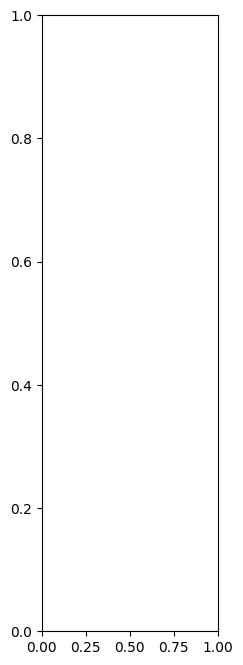

In [ ]:
import matplotlib.pyplot as plt
for i in range(4,10):
    plt.figure(figsize = (5,8))
    plt.subplot(1,2,1)
    plt.imshow(pred[i], cmap="gray")    # show the mask values only..boolean 1 0 shows too drastic value
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.figure(figsize = (5,8))
    plt.imshow(X_test[i], cmap="gray")    # show the mask values only..boolean 1 0 shows too drastic values
    plt.title("Original")
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step


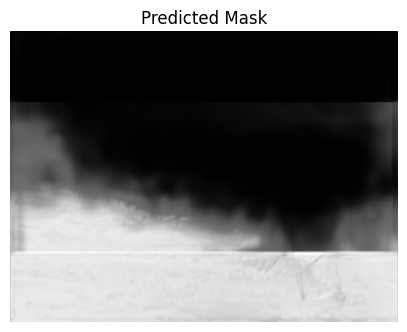

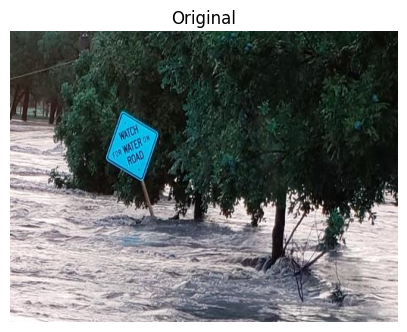